In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import os
os.makedirs("results/logistic_regression", exist_ok=True)

In [2]:
def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

In [3]:
def calculate_gradient(theta, X, y):
    m = y.size
    # X already has bias column prepended by gradient_descent
    return (X.T @ (sigmoid(X @ theta) - y)) / m

In [5]:
def gradient_descent(X, y, alpha=0.1, num_iter=100, tol=1e-7):
    X_b = np.c_[np.ones(X.shape[0]), X]
    theta = np.zeros(X_b.shape[1])
    for i in range(num_iter):
        grad = calculate_gradient(theta, X_b, y)   # pass X_b, not X
        theta -= alpha * grad
        if np.linalg.norm(grad) < tol:
            break
    return theta


def predict_prob(X, theta): # Will give us the probability between 0 and 1
    X_b = np.c_[np.ones(X.shape[0]), X]
    return sigmoid(X_b @ theta)

def predict(X, theta, threshold=0.5):
    return (predict_prob(X, theta) >= threshold).astype(int)



In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [7]:
df = pd.read_csv("telco_churn_cleaned.csv")

In [8]:
print(df["Churn"].unique())

[0 1]


In [32]:
print(df.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')


In [9]:
y = df["Churn"] #Target
X = df.drop(columns=["Churn"]) #Features
print(X.dtypes)

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                            int64
StreamingTV_No inter

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = X_train_scaled.astype(float)

X_test_scaled = scaler.transform(X_test)
X_test_scaled = X_test_scaled.astype(float)

y_train = y_train.values
y_test = y_test.values

theta_hat = gradient_descent(X_train_scaled, y_train, alpha=0.1)
y_pred_train = predict(X_train_scaled, theta_hat)
y_pred_test = predict(X_test_scaled, theta_hat)
y_prob_test = predict_prob(X_test_scaled, theta_hat)


train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)


Logistic Regression Results
------------------------------
Accuracy:  0.7918
Precision: 0.6188
Recall:    0.5642
F1-Score:  0.5902
ROC-AUC:   0.8312

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1033
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



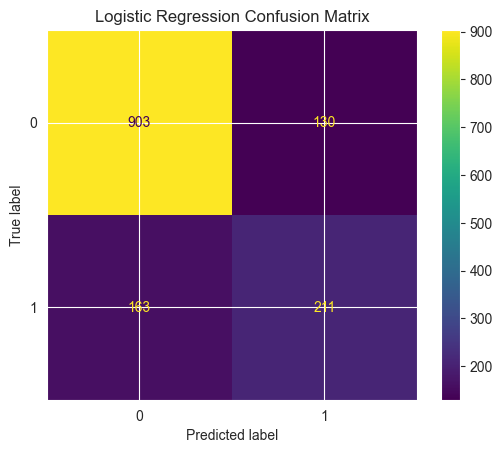

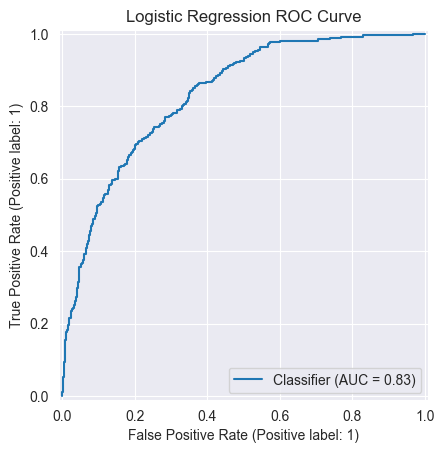


Files saved to results/logistic_regression/


In [11]:
# Calculate metrics
print("Logistic Regression Results")
print("-" * 30)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_test):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title("Logistic Regression Confusion Matrix")
plt.savefig("results/logistic_regression/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_test)
plt.title("Logistic Regression ROC Curve")
plt.savefig("results/logistic_regression/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

# Create results dataframe
results_df = pd.DataFrame([{
    "Model": "Baseline Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_test),
    "Precision": precision_score(y_test, y_pred_test),
    "Recall": recall_score(y_test, y_pred_test),
    "F1": f1_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score(y_test, y_prob_test)
}])

# Create test predictions dataframe
test_predictions = pd.DataFrame(X_test_scaled, columns=X.columns)
test_predictions["y_true"] = y_test
test_predictions["lr_prob"] = y_prob_test
test_predictions["lr_pred"] = y_pred_test

# Save CSVs
results_df.to_csv("results/logistic_regression/lr_model_comparison.csv", index=False)
test_predictions.to_csv("results/logistic_regression/lr_test_predictions.csv", index=False)

print("\nFiles saved to results/logistic_regression/")

In [14]:
print("The model looks at 374 actual churners in the test set, and only catches 56% of them. That means 44% of real churners are being missed and walk out the door without any intervention. That's the key weakness of logistic regression as a baseline.\n")

print("This is exactly why the tuned Random Forest (threshold 0.46) is the better main model — its recall for churners jumps to 0.735, meaning it catches 73.5% of churners instead of just 56%. Meaning we are catching significantly more of the people who are actually about to leave, which is the whole point of building this model in the first place.\n")

print("This is also the business justification for lowering the threshold from 0.5 to 0.46 in the RF model — accepting slightly more false alarms (lower precision) in exchange for catching more real churners (higher recall), which is almost always the right trade-off in churn prediction because the cost of losing a customer typically far outweighs the cost of sending an unnecessary retention offer.\n")

The model looks at 374 actual churners in the test set, and only catches 56% of them. That means 44% of real churners are being missed and walk out the door without any intervention. That's the key weakness of logistic regression as a baseline.

This is exactly why the tuned Random Forest (threshold 0.46) is the better main model — its recall for churners jumps to 0.735, meaning it catches 73.5% of churners instead of just 56%. Meaning we are catching significantly more of the people who are actually about to leave, which is the whole point of building this model in the first place.

This is also the business justification for lowering the threshold from 0.5 to 0.46 in the RF model — accepting slightly more false alarms (lower precision) in exchange for catching more real churners (higher recall), which is almost always the right trade-off in churn prediction because the cost of losing a customer typically far outweighs the cost of sending an unnecessary retention offer.



In [12]:
# Threshold tuning on training set using cross-validation
from sklearn.model_selection import cross_val_predict, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

# Need sklearn LR for cross_val_predict, or loop manually over folds
thresholds = np.arange(0.20, 0.81, 0.02)
best_threshold = 0.5
best_f1 = 0

# Use training probabilities from your existing model
train_prob = predict_prob(X_train_scaled, theta_hat)

for thr in thresholds:
    pred = (train_prob >= thr).astype(int)
    score = f1_score(y_train, pred)
    if score > best_f1:
        best_f1 = score
        best_threshold = thr

print(f"Best threshold: {best_threshold:.2f}")

# Apply to test set
y_pred_tuned = predict(X_test_scaled, theta_hat, threshold=best_threshold)
print(classification_report(y_test, y_pred_tuned))

Best threshold: 0.40
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1033
           1       0.54      0.70      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407



In [15]:
print("To further test the capabilities of Logistic Regression, we decided to further tune the model with a better threshold.\n")

print("The assumption was that Threshold tuning would add further complexity but a little meaningful improvement, because the underlying model is the same - the ROC-AUC doesn't move. The linear nature of logistic regression limits its discriminative power regardless of where you set the threshold. This is why we use it purely as an untuned baseline.\n")
print("The results proof the assumption, that the ROC-AUC is identical (0.8312). ROC-AUC does not change with threshold tuning, because it measures the model's ability to separate churners from non-churners across all thresholds. Lowering the threshold to 0.38 just moves along the same ROC curve, it does not make the model better fundamentally.\n")
print("What threshold tuning does is to trade precision for recall. Recall from churners jump from o.56 to 0.70 but precision drops from 0.62 to 0.52, and accuracy falls from 0.79 to 0.76.\n")

To further test the capabilities of Logistic Regression, we decided to further tune the model with a better threshold.

The assumption was that Threshold tuning would add further complexity but a little meaningful improvement, because the underlying model is the same - the ROC-AUC doesn't move. The linear nature of logistic regression limits its discriminative power regardless of where you set the threshold. This is why we use it purely as an untuned baseline.

The results proof the assumption, that the ROC-AUC is identical (0.8312). ROC-AUC does not change with threshold tuning, because it measures the model's ability to separate churners from non-churners across all thresholds. Lowering the threshold to 0.38 just moves along the same ROC curve, it does not make the model better fundamentally.

What threshold tuning does is to trade precision for recall. Recall from churners jump from o.56 to 0.70 but precision drops from 0.62 to 0.52, and accuracy falls from 0.79 to 0.76.

